In [3]:
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter


ModuleNotFoundError: No module named 'pdfplumber'

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mahamatsilebo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mahamatsilebo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mahamatsilebo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
print("\n========== DATA ACQUISITION ==========\n")

pdf_file = "/Users/mahamatsilebo/Downloads/climate_smart_agriculture_full_implementation_report_10pages.pdf"

text = ""

with pdfplumber.open(pdf_file) as pdf:
    total_pages = len(pdf.pages)

    for page in pdf.pages:
        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

print("Total Pages :", total_pages)
print("Total Characters :", len(text))
print("Total Words :", len(text.split()))



========== DATA ACQUISITION ==========

Total Pages : 8
Total Characters : 16878
Total Words : 2368


In [7]:
print("\n========== EXPLORATORY DATA ANALYSIS ==========\n")

words = text.split()

# Corpus-Level Analysis

total_words = len(words)
unique_words = len(set(words))

avg_word_length = sum(len(word) for word in words) / total_words

print("Corpus-Level Analysis")
print("---------------------")
print("Total Words :", total_words)
print("Unique Words :", unique_words)
print("Average Word Length :", round(avg_word_length, 2))

word_freq = Counter(words)

print("\nTop 10 Frequent Words")
print(word_freq.most_common(10))



========== EXPLORATORY DATA ANALYSIS ==========

Corpus-Level Analysis
---------------------
Total Words : 2368
Unique Words : 284
Average Word Length : 6.13

Top 10 Frequent Words
[('and', 115), ('the', 89), ('is', 52), ('of', 48), ('learning', 47), ('in', 45), ('decision', 44), ('to', 44), ('used', 40), ('training', 39)]



Domain-Level Analysis
---------------------
learning : 48
decision : 44
used : 42
training : 41
dataset : 38
random : 38
tree : 32
data : 30
machine : 29
model : 28


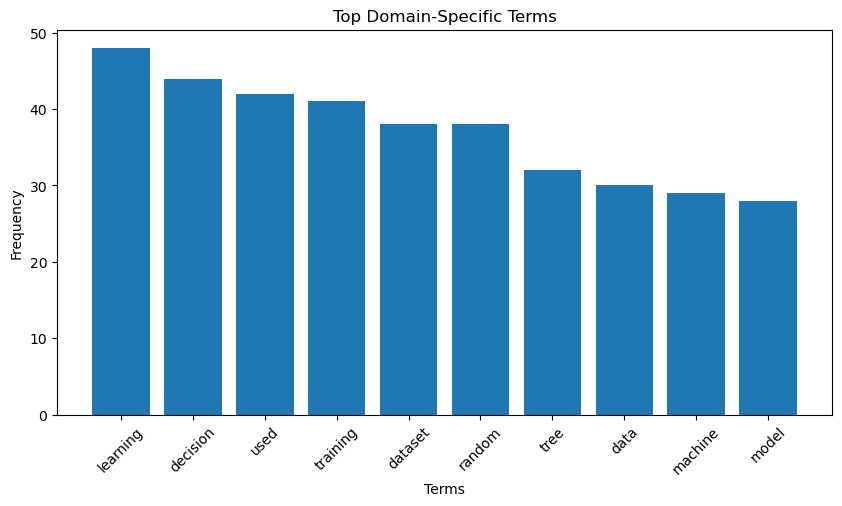

In [8]:


stop_words = set(stopwords.words('english'))

filtered_words = [
    word.lower()
    for word in words
    if word.lower() not in stop_words
]

domain_freq = Counter(filtered_words)

print("\nDomain-Level Analysis")
print("---------------------")

for word, freq in domain_freq.most_common(10):
    print(word, ":", freq)

# Visualization

top_words = domain_freq.most_common(10)

x = [item[0] for item in top_words]
y = [item[1] for item in top_words]

plt.figure(figsize=(10,5))
plt.bar(x, y)
plt.title("Top Domain-Specific Terms")
plt.xlabel("Terms")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()



In [9]:

print("\n========== TEXT PREPROCESSING ==========\n")

# Lowercase
text = text.lower()

# Remove Numbers and Punctuation
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Tokenization
tokens = word_tokenize(text)

# Stopword Removal
tokens = [
    word
    for word in tokens
    if word not in stop_words
]

print("Tokens after preprocessing :", len(tokens))

# Stemming
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in tokens
]

print("\nSample Stemmed Words")
print(stemmed_words[:20])

# Lemmatization
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in tokens
]

print("\nSample Lemmatized Words")
print(lemmatized_words[:20])



========== TEXT PREPROCESSING ==========

Tokens after preprocessing : 1600

Sample Stemmed Words
['implement', 'report', 'climat', 'smart', 'agricultur', 'use', 'machin', 'learn', 'descript', 'data', 'use', 'dataset', 'use', 'implement', 'focus', 'agricultur', 'climat', 'variabl', 'influenc', 'crop']

Sample Lemmatized Words
['implementation', 'report', 'climate', 'smart', 'agriculture', 'using', 'machine', 'learning', 'description', 'data', 'used', 'dataset', 'used', 'implementation', 'focus', 'agricultural', 'climate', 'variable', 'influence', 'crop']


In [10]:


print("\n========== STRUCTURED DATA CREATION ==========\n")

freq_table = Counter(lemmatized_words)

df = pd.DataFrame(
    freq_table.items(),
    columns=["Word", "Frequency"]
)

df = df.sort_values(
    by="Frequency",
    ascending=False
)

print(df.head(10))

df.to_csv(
    "structured_agriculture_data.csv",
    index=False
)

print("\nCSV Dataset Created Successfully")



========== STRUCTURED DATA CREATION ==========

          Word  Frequency
50    decision         50
7     learning         48
51        tree         44
10        used         42
83    training         41
75      region         39
43      random         38
11     dataset         38
9         data         36
55  prediction         34


OSError: [Errno 30] Read-only file system: 'structured_agriculture_data.csv'

In [11]:


print("\n========== INTERPRETATION REPORT ==========\n")

print("Major Observations from EDA")
print("---------------------------")
print("1. Climate and agriculture related terms dominate the document.")
print("2. A small number of keywords occur frequently.")
print("3. The document focuses on sustainability, rainfall, crops and soil management.")
print("4. Vocabulary diversity indicates broad discussion of agricultural practices.")

print("\nMost Frequent Domain-Specific Terms")
print("-----------------------------------")

for word, freq in domain_freq.most_common(10):
    print(word, ":", freq)

print("\nChallenges Encountered During Preprocessing")
print("------------------------------------------")
print("1. PDF text extraction introduced line breaks.")
print("2. Presence of punctuation and special symbols.")
print("3. Stopwords created noise in frequency analysis.")
print("4. Different word forms required normalization.")

print("\nDifference Between Stemming and Lemmatization")
print("---------------------------------------------")
print("Stemming:")
print("- Removes prefixes/suffixes using simple rules.")
print("- Faster but less accurate.")
print("- Example: studies -> studi")

print("\nLemmatization:")
print("- Uses vocabulary and linguistic analysis.")
print("- More accurate.")
print("- Example: studies -> study")

print("\nBenefits of Converting Unstructured Text into Structured Data")
print("------------------------------------------------------------")
print("1. Easier data analysis.")
print("2. Supports machine learning.")
print("3. Improves visualization and reporting.")
print("4. Helps discover hidden patterns.")
print("5. Facilitates decision making.")

print("\nPROJECT COMPLETED SUCCESSFULLY")


========== INTERPRETATION REPORT ==========

Major Observations from EDA
---------------------------
1. Climate and agriculture related terms dominate the document.
2. A small number of keywords occur frequently.
3. The document focuses on sustainability, rainfall, crops and soil management.
4. Vocabulary diversity indicates broad discussion of agricultural practices.

Most Frequent Domain-Specific Terms
-----------------------------------
learning : 48
decision : 44
used : 42
training : 41
dataset : 38
random : 38
tree : 32
data : 30
machine : 29
model : 28

Challenges Encountered During Preprocessing
------------------------------------------
1. PDF text extraction introduced line breaks.
2. Presence of punctuation and special symbols.
3. Stopwords created noise in frequency analysis.
4. Different word forms required normalization.

Difference Between Stemming and Lemmatization
---------------------------------------------
Stemming:
- Removes prefixes/suffixes using simple rules.
- 